# NanoVLM from scratch

In [1]:
import math, random
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

In [2]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print("Using device:", device)

Using device: cuda


In [3]:
IMG_SIZE = 32
EMBED_DIM = 32
BATCH_SIZE = 12
EPOCHS = 50
LR = 3e-4
TEMPERATURE = 0.07
ATTEN_HEADS = 4

## Synthetic dataset shaptes

In [4]:
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'pink', 'brown', 'gray']
shapes = ['square', 'circle', 'triangle']
positions = ['left', 'center', 'right', 'top', 'bottom','top-left', 'top-right', 'bottom-left', 'bottom-right']

In [5]:
def draw_sample(color, shape, position, img_size = IMG_SIZE):
  img = Image.new('RGB', (img_size, img_size), 'white')
  draw = ImageDraw.Draw(img)

  margin = 6
  h = w = img_size - 2*margin

  # x coordingates
  if 'left' in position:
    x0 = margin
    x1 = margin + w//2
  elif 'top-left' in position:
    x0 = margin
    x1 = margin + w//2
  elif 'bottom-left' in position:
    x0 = margin
    x1 = margin + w//2
  elif 'right' in position:
    x0 = margin + w//2
    x1 = img_size - margin
  elif 'top-right' in position:
    x0 = margin + w//2
    x1 = img_size - margin
  elif 'bottom-right' in position:
    x0 = margin + w//2
    x1 = img_size - margin
  else:
    x0 = margin + w//4
    x1 = margin + 3 * w//4

  # y coordingates
  if 'top' in position:
    y0 = margin
    y1 = margin + h//2
  elif 'top-left' in position:
    y0 = margin
    y1 = margin + h//2
  elif 'top-right' in position:
    y0 = margin
    y1 = margin + h//2
  elif 'bottom' in position:
    y0 = margin + h//2
    y1 = img_size - margin
  elif 'bottom-left' in position:
    y0 = margin + h//2
    y1 = img_size - margin
  elif 'bottom-right' in position:
    y0 = margin + h//2
    y1 = img_size - margin
  else:
    y0 = margin + h//4
    y1 = margin + 3 * h//4

  if shape == 'square':
    draw.rectangle([x0, y0, x1, y1], fill = color, outline='black')
  elif shape == 'circle':
    draw.ellipse([x0, y0, x1, y1], fill = color, outline='black')
  else: #triangle
    draw.polygon([((x1+x0)//2, y0), (x0, y1), (x1, y1)], fill = color, outline='black')

  return img


In [6]:
class ShapesDataset():
  def __init__(self):
    self.images = []
    self.captions = []

    for c in colors:
      for s in shapes:
        for p in positions:
          img = draw_sample(c, s, p)
          cap = f'{c} {s} {p}'

          self.images.append(torch.from_numpy(np.array(img)).permute(2, 0, 1).float()/255.0)
          self.captions.append(cap)

    self.vocab, self.word2idx = self.build_vocab(self.captions)

  def build_vocab(self, texts):
    words = sorted({w for t in texts for w in t.split()})
    vocab = ['[CLS]'] + words
    w2i = {w: i for i, w in enumerate(vocab)}
    return vocab, w2i

  def encode_text(self, text):
    toks = [self.word2idx['[CLS]']] + [self.word2idx[w] for w in text.split()]
    return torch.tensor(toks, dtype=torch.long)

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    return self.images[idx], self.encode_text(self.captions[idx]), self.captions[idx]

In [7]:
full_ds = ShapesDataset()
VOCAB_SIZE = len(full_ds.vocab)
print(VOCAB_SIZE)

22


In [8]:
train_size = int(0.8*len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size])

In [9]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)

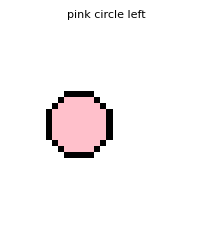

In [10]:
imgs, encoded_caps, raw_captions = next(iter(train_loader))
idx = random.randint(0, len(imgs) -1)
img = (imgs[idx].permute(1, 2, 0).numpy() * 255).astype(np.uint8)

# Use the raw caption directly
caption = raw_captions[idx]

plt.figure(figsize=(2.5, 2.5))
plt.imshow(img)
plt.title(caption, fontsize =8)
plt.axis('off')
plt.show()

In [11]:
class ImageEncoder(nn.Module):
  def __init__(self, embed_dim=EMBED_DIM):
    super().__init__()
    self.convolutions = nn.Sequential(
        nn.Conv2d(3, 32, 3, 2, 1),
        nn.ReLU(),
        nn.Conv2d(32, 64, 3, 2, 1),
        nn.ReLU(),
        nn.Conv2d(64, 128, 3, 2, 1),
        nn.ReLU(),
        nn.Conv2d(128, 256, 3, 2, 1),
        nn.ReLU()
    )

    self.projection = nn.Linear(256, embed_dim)
    self.layernorm1 = nn.LayerNorm(embed_dim)

  def forward(self, x):
    x = self.convolutions(x)
    x = x.mean(dim=[2, 3])
    x = self.projection(x)
    x = F.normalize(self.layernorm1(x), dim=-1)
    return x

In [12]:
class TextEncoder(nn.Module):
  def __init__(self, embed_dim=EMBED_DIM, num_heads = ATTEN_HEADS, vocab_size = VOCAB_SIZE, context_window = 4):
    super().__init__()
    self.token_embeddings = nn.Embedding(vocab_size, embed_dim)
    self.position_embedding = nn.Embedding(context_window, embed_dim)
    self.mha = nn.MultiheadAttention(embed_dim, num_heads)
    self.norm = nn.LayerNorm(embed_dim)
    self.projection = nn.Linear(embed_dim, embed_dim)

  def forward(self, toks):
    N, L = toks.shape
    position_emb_ids = torch.arange(L, device = toks.device).unsqueeze(0).expand(N, L)
    positions_embedding_vectors = self.position_embedding(position_emb_ids)
    token_embedding_vectors = self.token_embeddings(toks)
    x = token_embedding_vectors + positions_embedding_vectors
    x = x.permute(1, 0, 2) # MultiheadAttention expects (sequence_length, batch_size, embed_dim)
    x, _ = self.mha(x, x, x)
    x = x.permute(1, 0, 2) # Permute back to (batch_size, sequence_length, embed_dim)
    x = x[:,0] # Take the [CLS] token's embedding
    x = self.projection(x)
    x = F.normalize(self.norm(x), dim=-1)
    return x

In [13]:
def clip_loss(img_emb, txt_emb, temperature = TEMPERATURE):
  logits = img_emb @ txt_emb.T / temperature
  targets = torch.arange(img_emb.size(0), device = logits.device)
  loss_i = F.cross_entropy(logits, targets)
  loss_t = F.cross_entropy(logits.T, targets)
  return (loss_i + loss_t)/2.0

In [14]:
img_enc = ImageEncoder().to(device)
txt_enc = TextEncoder().to(device)
params = list(img_enc.parameters()) + list(txt_enc.parameters())
optimizer = torch.optim.Adam(params, lr = LR)

In [15]:
def show_image(t, title=None):
  img = (t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
  plt.figure(figsize=(2.2, 2.2))
  plt.axis('off')
  if title: plt.title(title, fontsize=8)
  plt.imshow(img); plt.show()

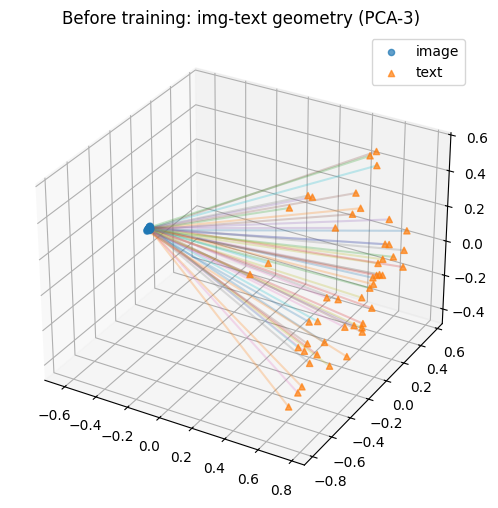

In [16]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

@torch.no_grad()
def collect_val_subset_embeddings(n=200):
  img_enc.eval(); txt_enc.eval()
  imgs_all, toks_all, caps_all = [], [], []
  for imgs, toks, caps in val_loader:
    imgs_all.append(imgs); toks_all.append(toks); caps_all += list(caps)
  imgs_all = torch.cat(imgs_all).to(device)
  toks_all = torch.cat(toks_all).to(device)

  n = min(n, imgs_all.size(0))
  idx = torch.randperm(imgs_all.size(0), device=device)[:n]

  imgs = imgs_all[idx]
  toks = toks_all[idx]
  caps = [caps_all[i] for i in idx.cpu().tolist()]

  img_emb = img_enc(imgs).detach().cpu().numpy()
  txt_emb = txt_enc(toks).detach().cpu().numpy()
  return idx.cpu().numpy(), imgs.cpu(), toks.cpu(), caps, img_emb, txt_emb

def pca3(x_np):
  x = x_np - x_np.mean(axis=0, keepdims=True)
  _, _, vt = np.linalg.svd(x, full_matrices=False)
  return x @ vt[:3].T

def plot_3d_pairs(img_emb_np, txt_emb_np, title="3D PCA (img, txt)"):
  both = np.concatenate([img_emb_np, txt_emb_np], axis=0)
  both3 = pca3(both)
  n = img_emb_np.shape[0]
  img3 = both3[:n]
  txt3 = both3[n:]

  fig = plt.figure(figsize=(7,6))
  ax = fig.add_subplot(111, projection="3d")
  ax.scatter(img3[:,0], img3[:,1], img3[:,2], marker="o", alpha=0.7, label="image")
  ax.scatter(txt3[:,0], txt3[:,1], txt3[:,2], marker="^", alpha=0.7, label="text")

  # connect matched pairs
  for i in range(n):
    ax.plot([img3[i,0], txt3[i,0]], [img3[i,1], txt3[i,1]], [img3[i,2], txt3[i,2]], alpha=0.25)

  ax.set_title(title)
  ax.legend()
  plt.show()

# Snapshot before training
subset_idx, subset_imgs, subset_toks, subset_caps, pre_img_emb_np, pre_txt_emb_np = collect_val_subset_embeddings(n=200)

plot_3d_pairs(pre_img_emb_np, pre_txt_emb_np, title="Before training: img-text geometry (PCA-3)")

In [17]:
best_val = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS+1):
  img_enc.train(); txt_enc.train()
  total = 0.0

  for imgs, toks, _ in train_loader:
    imgs = imgs.to(device); toks = toks.to(device)
    optimizer.zero_grad (set_to_none=True)
    ie = img_enc (imgs); te = txt_enc(toks)
    loss = clip_loss (ie, te)
    loss.backward()
    optimizer.step()
    total += loss.item()*imgs.size(0)
  train_loss = total / len(train_ds)

  # quick val
  img_enc.eval(); txt_enc.eval()
  with torch.no_grad():
    vtotal, n = 0.0, 0
    for imgs, toks, _ in val_loader:
      imgs = imgs.to(device); toks = toks.to(device)
      vtotal += clip_loss (img_enc(imgs), txt_enc(toks)).item()*imgs.size(0)
      n += imgs.size(0)
    val_loss = vtotal / n

  print (f" Epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}")
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  best_val = min(best_val, val_loss)

 Epoch 01 | train 2.5362 | val 2.4099
 Epoch 02 | train 2.3110 | val 2.0691
 Epoch 03 | train 1.6204 | val 1.3423
 Epoch 04 | train 0.9854 | val 0.8905
 Epoch 05 | train 0.5666 | val 0.5806
 Epoch 06 | train 0.4139 | val 0.4213
 Epoch 07 | train 0.3680 | val 0.3246
 Epoch 08 | train 0.3395 | val 0.2720
 Epoch 09 | train 0.2792 | val 0.3648
 Epoch 10 | train 0.2907 | val 0.3589
 Epoch 11 | train 0.3490 | val 0.3634
 Epoch 12 | train 0.2300 | val 0.2588
 Epoch 13 | train 0.1180 | val 0.2219
 Epoch 14 | train 0.1433 | val 0.3276
 Epoch 15 | train 0.1652 | val 0.2634
 Epoch 16 | train 0.1363 | val 0.3213
 Epoch 17 | train 0.1854 | val 0.2467
 Epoch 18 | train 0.0981 | val 0.1471
 Epoch 19 | train 0.1204 | val 0.1723
 Epoch 20 | train 0.0983 | val 0.1504
 Epoch 21 | train 0.1078 | val 0.1388
 Epoch 22 | train 0.1083 | val 0.1816
 Epoch 23 | train 0.1008 | val 0.1790
 Epoch 24 | train 0.0656 | val 0.1086
 Epoch 25 | train 0.0952 | val 0.1836
 Epoch 26 | train 0.0740 | val 0.0696
 Epoch 27 | 

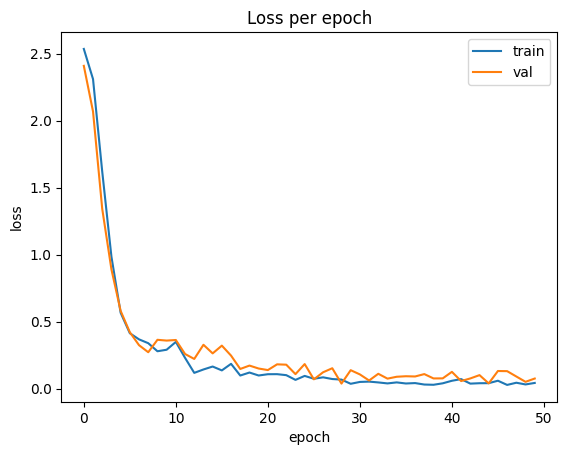

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss per epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

## Embeddings after training

In [19]:
def plot_embedding(embedding_np, title):
  plt.figure(figsize=(6, 2))
  plt.plot(embedding_np)
  plt.title(title)
  plt.xlabel("Dimension")
  plt.ylabel("Value")
  plt.grid(True)
  plt.show()

Sample image and caption for embeddings visualization: 'green square bottom-left'


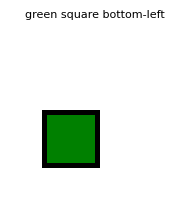

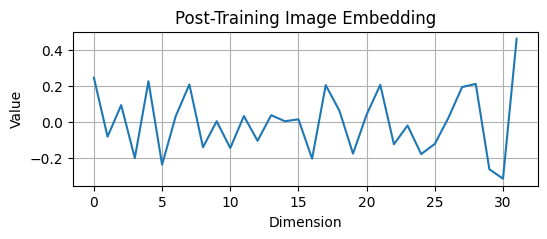

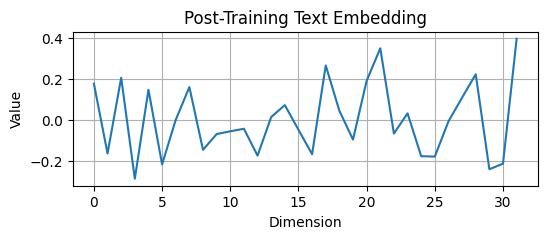

In [20]:
img_enc.eval(); txt_enc.eval()
with torch.no_grad():
  # Use a random index from the validation subset
  random_idx_in_subset = np.random.randint(0, len(subset_idx))
  actual_full_ds_idx = subset_idx[random_idx_in_subset]

  sample_img, sample_toks, sample_cap = full_ds[actual_full_ds_idx]
  sample_img = sample_img.unsqueeze (0).to(device)
  sample_toks = sample_toks.unsqueeze (0).to(device)
  post_train_img_emb = img_enc(sample_img).squeeze (0).cpu().numpy()
  post_train_txt_emb = txt_enc(sample_toks).squeeze(0).cpu().numpy()

# Display the sample image and caption
print (f"Sample image and caption for embeddings visualization: '{sample_cap}'")
show_image(sample_img.squeeze (0).cpu(), title=sample_cap)

plot_embedding(post_train_img_emb, "Post-Training Image Embedding")
plot_embedding(post_train_txt_emb, "Post-Training Text Embedding")

Sample image and caption for embeddings visualization: 'red triangle bottom'


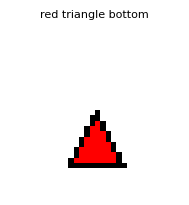

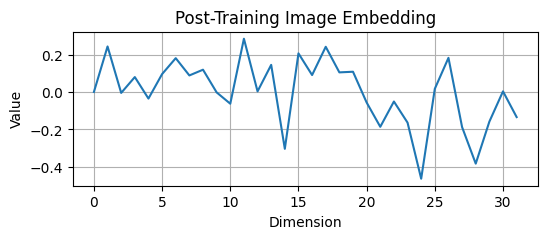

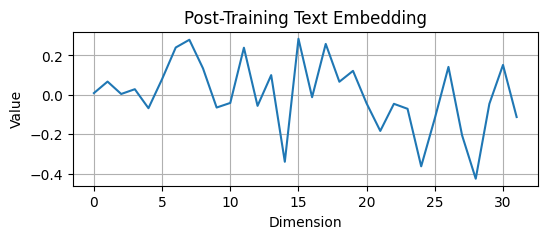

In [21]:
img_enc.eval(); txt_enc.eval()
with torch.no_grad():
  # Use a random index from the validation subset for post-training visualization
  random_idx_in_subset = np.random.randint(0, len(subset_idx))
  actual_full_ds_idx = subset_idx[random_idx_in_subset]

  sample_img, sample_toks, sample_cap = full_ds[actual_full_ds_idx]
  sample_img = sample_img.unsqueeze (0).to(device)
  sample_toks = sample_toks.unsqueeze (0).to(device)
  post_train_img_emb = img_enc(sample_img).squeeze (0).cpu().numpy()
  post_train_txt_emb = txt_enc(sample_toks).squeeze(0).cpu().numpy()

# Display the sample image and caption
print (f"Sample image and caption for embeddings visualization: '{sample_cap}'")
show_image(sample_img.squeeze (0).cpu(), title=sample_cap)

plot_embedding(post_train_img_emb, "Post-Training Image Embedding")
plot_embedding(post_train_txt_emb, "Post-Training Text Embedding")

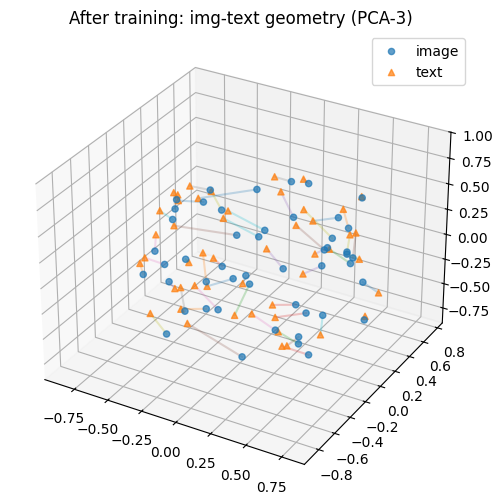

In [22]:
# After training snapshot on the same subset
img_enc.eval(); txt_enc.eval()
with torch.no_grad():
  post_img_emb_np = img_enc(subset_imgs.to(device)).detach().cpu().numpy()
  post_txt_emb_np = txt_enc(subset_toks.to(device)).detach().cpu().numpy()

plot_3d_pairs(post_img_emb_np, post_txt_emb_np, title="After training: img-text geometry (PCA-3)")

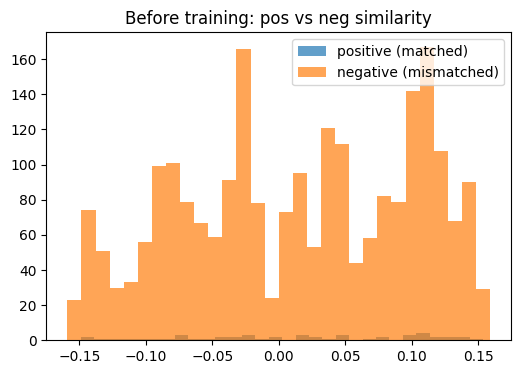

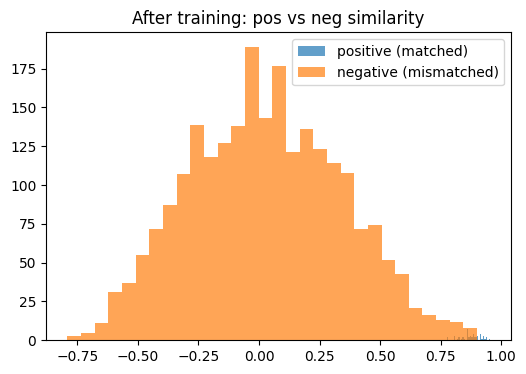

In [23]:
def plot_pos_neg(img_emb_np, txt_emb_np, title="Pos vs neg cosine similarity"):
  sim = img_emb_np @ txt_emb_np.T
  pos = np.diag(sim)
  neg = sim[~np.eye(sim.shape[0], dtype=bool)]

  plt.figure(figsize=(6,4))
  plt.hist(pos, bins=30, alpha=0.7, label="positive (matched)")
  plt.hist(neg, bins=30, alpha=0.7, label="negative (mismatched)")
  plt.title(title)
  plt.legend()
  plt.show()

plot_pos_neg(pre_img_emb_np, pre_txt_emb_np, title="Before training: pos vs neg similarity")
plot_pos_neg(post_img_emb_np, post_txt_emb_np, title="After training: pos vs neg similarity")

R@1 i2t: 0.959
R@1 t2i: 1.000
R@3 i2t: 1.000
R@3 t2i: 1.000
R@5 i2t: 1.000
R@5 t2i: 1.000
R@10 i2t: 1.000
R@10 t2i: 1.000


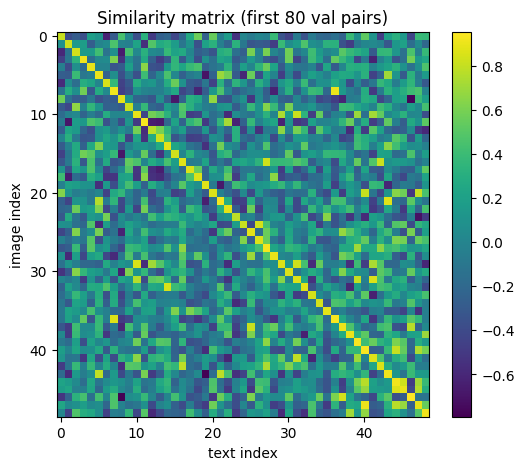

In [24]:
@torch.no_grad()
def recall_at_k(img_emb, txt_emb, ks=(1,3,5,10)):
  sim = img_emb @ txt_emb.T
  N = sim.size(0)
  ranks_i2t = sim.argsort(dim=1, descending=True)
  ranks_t2i = sim.T.argsort(dim=1, descending=True)

  results = {}
  gt = torch.arange(N, device=sim.device)
  for k in ks:
    r_i2t = (ranks_i2t[:, :k] == gt.unsqueeze(1)).any(dim=1).float().mean().item()
    r_t2i = (ranks_t2i[:, :k] == gt.unsqueeze(1)).any(dim=1).float().mean().item()
    results[f"R@{k} i2t"] = r_i2t
    results[f"R@{k} t2i"] = r_t2i
  return results

# Generate embeddings for the full validation set
img_enc.eval(); txt_enc.eval()
with torch.no_grad():
  val_imgs, val_toks, val_caps = [], [], []
  for imgs, toks, caps in val_loader:
    val_imgs.append(imgs); val_toks.append(toks); val_caps += list(caps)
  val_imgs = torch.cat(val_imgs).to(device)
  val_toks = torch.cat (val_toks).to(device)
  img_emb = img_enc(val_imgs)
  txt_emb = txt_enc(val_toks)

metrics = recall_at_k(img_emb, txt_emb, ks=(1,3,5,10))
for k,v in metrics.items():
  print(f"{k}: {v:.3f}")

# Heatmap (optional, use first 80 for readability)
import matplotlib.pyplot as plt
sim_small = (img_emb[:80] @ txt_emb[:80].T).detach().cpu().numpy()
plt.figure(figsize=(6,5))
plt.imshow(sim_small, aspect="auto")
plt.title("Similarity matrix (first 80 val pairs)")
plt.xlabel("text index")
plt.ylabel("image index")
plt.colorbar()
plt.show()

In [25]:
def topk_text_for_images(k=3, idxs=None):
  if idxs is None: idxs = np.random. choice(len(val_caps), size=1, replace=False)
  sims = (img_emb @ txt_emb.t())
  for i in idxs:
    best = sims[i].topk(k).indices.tolist()
    print (f"\nImage {i} best captions:")
    for j in best:
      print("-", val_caps[j])
    show_image(val_imgs[i].cpu())

def topk_images_for_text (k=3, idxs=None):
  if idxs is None: idxs = np.random. choice(len(val_caps), size=1, replace=False)
  sims = (txt_emb @ img_emb.t())
  for i in idxs:
    best = sims[i].topk(k).indices.tolist()
    print(f"\nText '{val_caps [i]}' best images: ")
    for j in best:
      show_image(val_imgs[j].cpu(), title=f"match {val_caps [j]}")

In [26]:
import ipywidgets as widgets
from IPython.display import display, clear_output

cap2idx = {c:i for i,c in enumerate(val_caps)}

query = widgets.Text(value=val_caps[0], description="Text:", layout=widgets.Layout(width="700px"))
topk = widgets.IntSlider(value=3, min=1, max=10, step=1, description="Top-k:")
btn = widgets.Button(description="Search images")
out = widgets.Output()

@torch.no_grad()
def run(_):
  with out:
    clear_output()
    q = query.value.strip()
    if q not in cap2idx:
      print("Not found in this toy dataset captions. Try one of these:")
      for s in val_caps[:5]:
        print("-", s)
      return

    i = cap2idx[q]
    sims = (txt_emb[i] @ img_emb.T)
    best = torch.topk(sims, k=topk.value).indices.tolist()

    print(f"Query: '{q}'")
    for r, j in enumerate(best, 1):
      show_image(val_imgs[j].cpu(), title=f"{r}) score={sims[j].item():.3f} | {val_caps[j]}")

btn.on_click(run)
display(widgets.VBox([query, topk, btn, out]))

In [27]:
try:
    import onnxscript
except ImportError:
    !pip install onnxscript
    import onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 18.0 MB/s eta 0:00:00


In [28]:
import json
from pathlib import Path
import torch

def export_nanovlm_for_web_single_file(output_dir="./nanovlm-export", opset_version=17):
    img_enc.eval()
    txt_enc.eval()

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    image_onnx_path = out_dir / "nanovlm-image-encoder.onnx"
    text_onnx_path = out_dir / "nanovlm-text-encoder.onnx"
    vocab_json_path = out_dir / "nanovlm-vocab.json"
    config_json_path = out_dir / "nanovlm-config.json"

    img_cpu = img_enc.to("cpu").eval()
    txt_cpu = txt_enc.to("cpu").eval()

    dummy_image = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, dtype=torch.float32, device="cpu")
    dummy_tokens = torch.zeros(1, 4, dtype=torch.long, device="cpu")

    torch.onnx.export(
        img_cpu,
        dummy_image,
        str(image_onnx_path),
        input_names=["image"],
        output_names=["image_embedding"],
        dynamic_axes={"image": {0: "batch"}, "image_embedding": {0: "batch"}},
        opset_version=opset_version,
        do_constant_folding=True,
        export_params=True,
        dynamo=False,
        external_data=False,
    )

    torch.onnx.export(
        txt_cpu,
        dummy_tokens,
        str(text_onnx_path),
        input_names=["tokens"],
        output_names=["text_embedding"],
        dynamic_axes={"tokens": {0: "batch"}, "text_embedding": {0: "batch"}},
        opset_version=opset_version,
        do_constant_folding=True,
        export_params=True,
        dynamo=False,
        external_data=False,
    )

    with open(vocab_json_path, "w", encoding="utf-8") as f:
        json.dump(
            {"vocab": full_ds.vocab, "word2idx": full_ds.word2idx},
            f,
            indent=2,
        )

    metrics_payload = {}
    if "metrics" in globals() and isinstance(metrics, dict):
        metrics_payload = {k: float(v) for k, v in metrics.items()}

    with open(config_json_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "img_size": int(IMG_SIZE),
                "embed_dim": int(EMBED_DIM),
                "attention_heads": int(ATTEN_HEADS),
                "context_window": 4,
                "token_format": "[CLS] color shape position",
                "temperature": float(TEMPERATURE),
                "metrics": metrics_payload,
            },
            f,
            indent=2,
        )

    print("Export complete (single-file ONNX):")
    print("-", image_onnx_path)
    print("-", text_onnx_path)
    print("-", vocab_json_path)
    print("-", config_json_path)

export_nanovlm_for_web_single_file("./nanovlm-export")

/tmp/ipython-input-326/4068917001.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/tmp/ipython-input-326/4068917001.py:40: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Export complete (single-file ONNX):
- nanovlm-export/nanovlm-image-encoder.onnx
- nanovlm-export/nanovlm-text-encoder.onnx
- nanovlm-export/nanovlm-vocab.json
- nanovlm-export/nanovlm-config.json


In [29]:
def export_embeddings_2d_json(
    pre_embeddings,
    post_embeddings,
    captions,
    output_dir="./nanovlm-export",
    filename="nanovlm-embeddings-2d.json",
):
    pre = np.asarray(pre_embeddings, dtype=np.float32)
    post = np.asarray(post_embeddings, dtype=np.float32)

    n = min(len(pre), len(post), len(captions))
    pre = pre[:n]
    post = post[:n]
    caps = list(captions[:n])

    both = np.concatenate([pre, post], axis=0)
    both_centered = both - both.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(both_centered, full_matrices=False)
    both_2d = both_centered @ vt[:2].T

    payload = {
        "before": both_2d[:n].tolist(),
        "after": both_2d[n:].tolist(),
        "captions": caps,
    }

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)

    print(f"Saved: {out_path}")
    print(f"Points: {n}")

export_embeddings_2d_json(
    pre_embeddings=pre_img_emb_np,
    post_embeddings=post_img_emb_np,
    captions=subset_caps,
    output_dir="./nanovlm-export",
)

Saved: nanovlm-export/nanovlm-embeddings-2d.json
Points: 49
